In [35]:
import warnings
warnings.filterwarnings('ignore')

In [36]:
import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
import ast
from sklearn.cluster import KMeans

from rapidfuzz import fuzz, process
import unicodedata

import joblib
import re

In [37]:
us_state_to_abbrev = {
    "Alabama": "AL",
    "Alaska": "AK",
    "Arizona": "AZ",
    "Arkansas": "AR",
    "California": "CA",
    "Colorado": "CO",
    "Connecticut": "CT",
    "Delaware": "DE",
    "Florida": "FL",
    "Georgia": "GA",
    "Hawaii": "HI",
    "Idaho": "ID",
    "Illinois": "IL",
    "Indiana": "IN",
    "Iowa": "IA",
    "Kansas": "KS",
    "Kentucky": "KY",
    "Louisiana": "LA",
    "Maine": "ME",
    "Maryland": "MD",
    "Massachusetts": "MA",
    "Michigan": "MI",
    "Minnesota": "MN",
    "Mississippi": "MS",
    "Missouri": "MO",
    "Montana": "MT",
    "Nebraska": "NE",
    "Nevada": "NV",
    "New Hampshire": "NH",
    "New Jersey": "NJ",
    "New Mexico": "NM",
    "New York": "NY",
    "North Carolina": "NC",
    "North Dakota": "ND",
    "Ohio": "OH",
    "Oklahoma": "OK",
    "Oregon": "OR",
    "Pennsylvania": "PA",
    "Rhode Island": "RI",
    "South Carolina": "SC",
    "South Dakota": "SD",
    "Tennessee": "TN",
    "Texas": "TX",
    "Utah": "UT",
    "Vermont": "VT",
    "Virginia": "VA",
    "Washington": "WA",
    "West Virginia": "WV",
    "Wisconsin": "WI",
    "Wyoming": "WY",
    "District of Columbia": "DC",
    "American Samoa": "AS",
    "Guam": "GU",
    "Northern Mariana Islands": "MP",
    "Puerto Rico": "PR",
    "United States Minor Outlying Islands": "UM",
    "Virgin Islands, U.S.": "VI",
} 

abbrev_to_us_state = dict(map(reversed, us_state_to_abbrev.items()))
# https://gist.github.com/rogerallen/1583593

In [38]:
data = pd.read_csv('transformed/past_house_results.csv')
data = data[data['year'] >= 2014]
data.head()

,year,state,state_po,special,district,dem,rep,totalvotes,dem_cand,rep_cand,...,dem_funds,rep_funds,2party_votes,dem_pct_2p,rep_pct_2p,dem_tot_funds,rep_tot_funds,tot_funds,dem_funds_2p_pct,rep_funds_2p_pct
435,2014,Alabama,AL,False,1,48278.0,103758.0,152234,Burton R Leflore,Bradley Byrne,...,33474.0,914507.3,152036.0,31.754321,68.245679,33474.0,914507.30,947981.30,3.531082,96.468918
436,2014,Alabama,AL,False,2,54692.0,113103.0,167952,Erick Wright,Martha Roby,...,6674.0,454019.64,167795.0,32.594535,67.405465,6674.0,454019.64,460693.64,1.448685,98.551315
437,2014,Alabama,AL,False,3,52816.0,103558.0,156620,Jesse T Smith,Mike Rogers,...,2100.0,504511.67,156374.0,33.775436,66.224564,2100.0,504511.67,506611.67,0.414519,99.585481
438,2014,Alabama,AL,False,4,NaN,132831.0,134752,[],Robert B Aderholt,...,[],419784.54,NaN,NaN,NaN,0.0,419784.54,419784.54,0.000000,100.000000
439,2014,Alabama,AL,False,5,NaN,115338.0,154974,[],Mo Brooks,...,[],321615.19,NaN,NaN,NaN,0.0,321615.19,321615.19,0.000000,100.000000


In [39]:
data.columns

Index(['year', 'state', 'state_po', 'special', 'district', 'dem', 'rep',
       'totalvotes', 'dem_cand', 'rep_cand', 'dem_inc', 'rep_inc', 'dem_funds',
       'rep_funds', '2party_votes', 'dem_pct_2p', 'rep_pct_2p',
       'dem_tot_funds', 'rep_tot_funds', 'tot_funds', 'dem_funds_2p_pct',
       'rep_funds_2p_pct'],
      dtype='object')

In [40]:
demo22_cols = ['district_name', 'district', 'white_pct', 'black_pct', 'hisp_pct', 'asn_pct',
                           'natam_pct', 'pi_pct', 'vap_white_pct', 'vap_black_pct', 'vap_hisp_pct', 'vap_asn_pct',
                           'vap_natam_pct', 'vap_pi_pct', 'cit_white_pct', 'cit_black_pct', 'cit_hisp_pct', 'cit_asn_pct',
                           'cit_natam_pct', 'cit_pi_pct', 'cvap_white_pct', 'cvap_black_pct', 'cvap_hisp_pct', 'cvap_asn_pct',
                           'cvap_natam_pct', 'cvap_pi_pct', 'tot_population', 'white_pop', 'black_pop', 'hisp_pop',
                           'asn_pop', 'natam_pop', 'pi_pop', 'vap_pop', 'white_vap_pop', 'black_vap_pop', 'hisp_vap_pop', 'asn_vap_pop',
                           'natam_vap_pop', 'pi_vap_pop', 'cit_pop', 'white_cit_pop', 'black_cit_pop', 'hisp_cit_pop', 'asn_cit_pop',
                           'natam_cit_pop', 'pi_cit_pop', 'cvap_pop', 'white_cvap_pop', 'black_cvap_pop', 'hisp_cvap_pop', 'asn_cvap_pop',
                           'natam_cvap_pop', 'pi_cvap_pop']

demo_cols = ['district_name', 'district', 'white_pct', 'black_pct', 'hisp_pct', 'aapi_pct',
                           'natam_pct', 'other_pct', 'vap_white_pct', 'vap_black_pct', 'vap_hisp_pct', 'vap_aapi_pct',
                           'vap_natam_pct', 'vap_other_pct', 'cit_white_pct', 'cit_black_pct', 'cit_hisp_pct', 'cit_aapi_pct',
                           'cit_natam_pct', 'cit_other_pct', 'cvap_white_pct', 'cvap_black_pct', 'cvap_hisp_pct', 'cvap_aapi_pct',
                           'cvap_natam_pct', 'cvap_other_pct', 'tot_population', 'white_pop', 'black_pop', 'hisp_pop',
                           'aapi_pop', 'natam_pop', 'other_pop', 'vap_pop', 'white_vap_pop', 'black_vap_pop', 'hisp_vap_pop', 'aapi_vap_pop',
                           'natam_vap_pop', 'other_vap_pop', 'cit_pop', 'white_cit_pop', 'black_cit_pop', 'hisp_cit_pop', 'aapi_cit_pop',
                           'natam_cit_pop', 'other_cit_pop', 'cvap_pop', 'white_cvap_pop', 'black_cvap_pop', 'hisp_cvap_pop', 'aapi_cvap_pop',
                           'natam_cvap_pop', 'other_cvap_pop']

In [41]:
filepath = f'data/demo/2014_114_demo_data/ACSDT5Y2014.B05003D-Data.csv'
demo_b = pd.read_csv(filepath)
demo_b.iloc[0, :].values[22], demo_b.iloc[0, :].values[44]

('Estimate!!Total!!Male!!18 years and over!!Foreign born!!Naturalized U.S. citizen',
 'Estimate!!Total!!Female!!18 years and over!!Foreign born!!Naturalized U.S. citizen')

In [42]:
demo_key = {
    '': 'tot',
    'B': 'black',
    'C': 'natam',
    'D': 'asn',
    'E': 'pi',
    'F': 'other_only',
    'G': 'multi',
    'H': 'white',
    'I': 'hisp'
}

demo_14 = pd.DataFrame()

for char in demo_key.keys():
    filepath = f'data/demo/2014_114_demo_data/ACSDT5Y2014.B05003{char}-Data.csv'
    demo_b = pd.read_csv(filepath)
    demo_b_ind = demo_b.iloc[1:, 0:2]
    demo_b_native_male = demo_b.iloc[1:, 18]
    demo_b_nonnat_cit_male = demo_b.iloc[1:, 22]
    demo_b_native_female = demo_b.iloc[1:, 40]
    demo_b_nonnat_cit_female = demo_b.iloc[1:, 44]
    if demo_14.empty:
        demo_b = pd.concat([demo_b_ind, demo_b_native_male, demo_b_nonnat_cit_male, demo_b_native_female, demo_b_nonnat_cit_female], axis=1)
        demo_b = demo_b.set_axis(['geoid', 'district_name', f'cvap_{demo_key[char]}_native_pop_M', f'cvap_{demo_key[char]}_foreign_pop_M',
                                 f'cvap_{demo_key[char]}_native_pop_F', f'cvap_{demo_key[char]}_foreign_pop_F'], axis=1)
        demo_14 = demo_b.copy()
    else:
        demo_b = pd.concat([demo_b_native_male, demo_b_nonnat_cit_male, demo_b_native_female, demo_b_nonnat_cit_female], axis=1)
        demo_b = demo_b.set_axis([f'cvap_{demo_key[char]}_native_pop_M', f'cvap_{demo_key[char]}_foreign_pop_M',
                                 f'cvap_{demo_key[char]}_native_pop_F', f'cvap_{demo_key[char]}_foreign_pop_F'], axis=1)
        demo_14 = pd.concat([demo_14, demo_b], axis=1)

for race in demo_key.values():
    for sex in ['M', 'F']:
        demo_14[f'cvap_{race}_native_pop_{sex}'] = demo_14[f'cvap_{race}_native_pop_{sex}'].astype(int)
        demo_14[f'cvap_{race}_foreign_pop_{sex}'] = demo_14[f'cvap_{race}_foreign_pop_{sex}'].astype(int)
    demo_14[f'cvap_{race}_pop'] = (demo_14[f'cvap_{race}_native_pop_M'] + demo_14[f'cvap_{race}_foreign_pop_M'] +
                                   demo_14[f'cvap_{race}_native_pop_F'] + demo_14[f'cvap_{race}_foreign_pop_F'])
    if race != 'tot':
        demo_14[f'cvap_{race}_pct'] = demo_14[f'cvap_{race}_pop'] / demo_14['cvap_tot_pop'] * 100

demo_14['cvap_aapi_pct'] = demo_14['cvap_asn_pct'] + demo_14['cvap_pi_pct']
demo_14['cvap_other_pct'] = demo_14['cvap_other_only_pct'] + demo_14['cvap_multi_pct']
demo_14[['seat_number', 'state']] = demo_14['district_name'].str.extract(r"Congressional District (\d+|\(at Large\)) \(114th Congress\), ([A-za-z\-\s]+)")
demo_14 = demo_14[~demo_14['seat_number'].isna()]
demo_14['district'] = demo_14['state'].map(us_state_to_abbrev) + '-' + demo_14['seat_number'].map(lambda x: '00' if (isinstance(x, str) and x == '(at Large)') else
                                                                                                 (f'0{x}' if int(x) < 10 else str(x)))
demo_14.head()

,geoid,district_name,cvap_tot_native_pop_M,cvap_tot_foreign_pop_M,cvap_tot_native_pop_F,cvap_tot_foreign_pop_F,cvap_black_native_pop_M,cvap_black_foreign_pop_M,cvap_black_native_pop_F,cvap_black_foreign_pop_F,...,cvap_multi_pct,cvap_white_pop,cvap_white_pct,cvap_hisp_pop,cvap_hisp_pct,cvap_aapi_pct,cvap_other_pct,seat_number,state,district
1,5001400US0101,"Congressional District 1 (114th Congress), Ala...",240694,3769,266883,4101,61673,79,74578,287,...,1.030368,356105,69.086637,8761,1.699690,0.821617,1.467076,1,Alabama,AL-01
2,5001400US0102,"Congressional District 2 (114th Congress), Ala...",242441,2844,264142,3899,68267,266,81448,276,...,1.168263,342963,66.811928,8836,1.721323,0.736959,1.541905,2,Alabama,AL-02
3,5001400US0103,"Congressional District 3 (114th Congress), Ala...",248760,2491,269204,3482,59489,377,70804,223,...,0.827771,377160,71.985754,7920,1.511632,0.582895,1.164453,3,Alabama,AL-03
4,5001400US0104,"Congressional District 4 (114th Congress), Ala...",241094,2643,261365,2815,16178,83,18627,106,...,1.279540,452947,89.177366,8373,1.648498,0.421526,1.598686,4,Alabama,AL-04
5,5001400US0105,"Congressional District 5 (114th Congress), Ala...",246417,5212,262075,6703,39987,767,46644,604,...,1.603745,404605,77.747801,11464,2.202891,1.083767,2.030526,5,Alabama,AL-05


In [43]:
demo_14['district_name'].iloc[1]

'Congressional District 2 (114th Congress), Alabama'

In [44]:
demo_16 = pd.read_csv('data/demo/2016_115_acs_demo.csv')
demo_16_index = demo_16.iloc[2:, 0:2]
demo_16_data = demo_16.iloc[2:, 20:26]
demo_16 = pd.concat([demo_16_index, demo_16_data], axis=1)
demo_16 = demo_16.set_axis(['district_name', 'district', 'cvap_white_pct', 'cvap_black_pct', 'cvap_hisp_pct', 
                            'cvap_aapi_pct', 'cvap_natam_pct', 'cvap_other_pct'],
                          axis=1)
demo_16['district'] = demo_16['district'].str.replace('-AL', '-00')
demo_16.head()

,district_name,district,cvap_white_pct,cvap_black_pct,cvap_hisp_pct,cvap_aapi_pct,cvap_natam_pct,cvap_other_pct
2,Alabama's 1st,AL-01,68.7,26.5,1.8,0.9,1.0,1.1
3,Alabama's 2nd,AL-02,66.1,29.9,1.8,0.7,0.4,1.1
4,Alabama's 3rd,AL-03,71.4,25.1,1.7,0.7,0.3,0.9
5,Alabama's 4th,AL-04,88.8,6.9,1.8,0.5,0.7,1.3
6,Alabama's 5th,AL-05,77.3,17.1,2.2,1.1,0.6,1.6


In [45]:
demo_18 = pd.read_csv('data/demo/2018_116_acs_demo.csv')
demo_18 = demo_18.iloc[2:]
demo_18 = demo_18.set_axis(demo_cols, axis=1)
demo_18['district'] = demo_18['district'].str.replace('-AL', '-00')
demo_18.head()

,district_name,district,white_pct,black_pct,hisp_pct,aapi_pct,natam_pct,other_pct,vap_white_pct,vap_black_pct,...,aapi_cit_pop,natam_cit_pop,other_cit_pop,cvap_pop,white_cvap_pop,black_cvap_pop,hisp_cvap_pop,aapi_cvap_pop,natam_cvap_pop,other_cvap_pop
2,Alabama's 1st,AL-01,65.2,27.6,3.2,1.5,1.0,1.4,67.6,26.0,...,"7,770","7,255","10,150","534,355","365,070","140,815","11,025","5,710","5,840","5,895"
3,Alabama's 2nd,AL-02,61.9,31.2,3.6,1.2,0.4,1.9,64.3,30.1,...,"4,610","2,540","12,605","516,040","336,825","157,445","9,980","3,250","2,045","6,495"
4,Alabama's 3rd,AL-03,67.8,25.4,3.1,1.8,0.3,1.6,69.5,24.9,...,"6,935","1,975","11,610","538,125","380,720","135,955","9,705","4,490","1,610","5,640"
5,Alabama's 4th,AL-04,83.7,6.9,6.5,0.6,0.7,1.6,85.9,6.9,...,"2,795","4,775","11,210","511,065","452,155","35,585","11,105","2,135","3,815","6,260"
6,Alabama's 5th,AL-05,72.8,17.4,5.1,1.7,0.6,2.4,74.8,17.0,...,"8,890","4,345","16,635","540,510","414,195","93,455","12,955","6,615","3,520","9,770"


In [46]:
demo_20 = pd.read_csv('data/demo/2019_117_acs_demo.csv')
demo_20 = demo_20.iloc[2:]
demo_20 = demo_20.set_axis(demo_cols, axis=1)
demo_20['district'] = demo_20['district'].str.replace('-AL', '-00')
demo_20.head()

,district_name,district,white_pct,black_pct,hisp_pct,aapi_pct,natam_pct,other_pct,vap_white_pct,vap_black_pct,...,aapi_cit_pop,natam_cit_pop,other_cit_pop,cvap_pop,white_cvap_pop,black_cvap_pop,hisp_cvap_pop,aapi_cvap_pop,natam_cvap_pop,other_cvap_pop
2,Alabama's 1st,AL-01,65.2,27.5,3.2,1.5,1.1,1.5,67.5,26.0,...,"8,140","7,600","10,570","538,420","367,555","141,810","10,985","5,950","5,820","6,300"
3,Alabama's 2nd,AL-02,61.5,31.2,3.7,1.2,0.4,1.9,64.0,30.2,...,"4,830","2,425","12,905","516,005","334,800","158,600","10,565","3,560","2,015","6,465"
4,Alabama's 3rd,AL-03,67.6,25.5,3.1,1.9,0.3,1.6,69.3,25.0,...,"7,085","1,930","11,560","540,935","381,805","137,270","9,705","4,475","1,545","6,135"
5,Alabama's 4th,AL-04,83.4,7.0,6.6,0.6,0.6,1.7,85.8,6.9,...,"2,820","4,360","11,720","511,775","452,235","35,895","11,320","2,085","3,600","6,640"
6,Alabama's 5th,AL-05,72.5,17.6,5.2,1.8,0.6,2.3,74.5,17.3,...,"9,810","4,185","16,210","546,480","417,040","95,765","13,420","7,185","3,430","9,640"


In [47]:
demo_22 = pd.read_csv('data/demo/2022_118_acs_demo.csv')
demo_22 = demo_22.iloc[2:]
demo_22 = demo_22.set_axis(demo22_cols, axis=1)
demo_22['district'] = demo_22['district'].str.replace('-AL', '-00')
demo_22['cvap_aapi_pct'] = demo_22['cvap_asn_pct'].astype(float) + demo_22['cvap_pi_pct'].astype(float) # Combine Asian and Pacific Islander percentages for consistency
demo_22.head()

,district_name,district,white_pct,black_pct,hisp_pct,asn_pct,natam_pct,pi_pct,vap_white_pct,vap_black_pct,...,natam_cit_pop,pi_cit_pop,cvap_pop,white_cvap_pop,black_cvap_pop,hisp_cvap_pop,asn_cvap_pop,natam_cvap_pop,pi_cvap_pop,cvap_aapi_pct
2,Alabama's 1st,AL-01,65.3,27.4,3.5,1.9,1.6,0.0,67.5,25.8,...,"11,655",105,"548,455","374,540","143,035","12,720","7,450","9,390",95,1.4
3,Alabama's 2nd,AL-02,60.6,32.0,4.1,2.1,1.0,0.0,63.2,30.5,...,"7,130",65,"540,250","347,310","168,065","11,665","6,995","5,850",50,1.3
4,Alabama's 3rd,AL-03,68.2,25.6,3.4,1.7,0.8,0.1,69.8,24.7,...,"5,665",400,"556,010","393,565","139,185","11,895","5,220","4,745",295,1.0
5,Alabama's 4th,AL-04,82.5,8.1,6.9,0.8,1.6,0.0,84.8,7.6,...,"11,380",280,"540,005","470,370","42,035","14,785","3,000","9,150",220,0.6
6,Alabama's 5th,AL-05,71.3,18.9,5.7,2.3,1.6,0.0,73.3,18.2,...,"11,135",305,"549,440","412,430","102,010","15,835","9,070","9,305",210,1.7


In [48]:
demo_24 = pd.read_csv('data/demo/2024_119_acs_demo_census.csv') # This is CVAP only
demo_24 = pd.pivot_table(demo_24, columns=['lntitle'], index=['geoname', 'geoid'], values='cvap_est', aggfunc='first')
demo_24 = demo_24.reset_index()
extr_tokens = demo_24['geoname'].str.extract(r"Congressional District (\(at Large\)|\d+) \(119th Congress\), ([A-za-z\s]+)")
demo_24 = pd.concat([demo_24, extr_tokens], axis=1)
demo_24 = demo_24.rename({0: 'seat_number', 1: 'state'}, axis=1)
demo_24 = demo_24[~demo_24['state'].isna()]
demo_24['district'] = demo_24['state'].astype(str).map(us_state_to_abbrev) + '-' + demo_24['seat_number'].map(lambda x: '00' if x == '(at Large)' else 
                                                                                                              (f'0{x}' if int(x) < 10 else f'{x}'))
demo_24 = demo_24.set_axis(['geoname', 'geoid', 'natam', 'natamXblack', 'natamXwhite', 'asn', 'asnXwhite', 'black', 'blackXwhite',
                           'hisp', 'pi', 'nothisp', 'multi', 'tot', 'white', 'seat_number', 'state', 'district'], axis=1)
demo_24['aapi'] = demo_24['asn'].astype(int) + demo_24['pi'].astype(int)
for race in ['natam', 'aapi', 'black', 'hisp', 'white', 'pi']:
    demo_24[f'cvap_{race}_pct'] = demo_24[race] / demo_24['tot'] * 100
demo_24 = demo_24.rename({'tot': 'cvap_pop'}, axis=1)
demo_24.head(7)

,geoname,geoid,natam,natamXblack,natamXwhite,asn,asnXwhite,black,blackXwhite,hisp,...,seat_number,state,district,aapi,cvap_natam_pct,cvap_aapi_pct,cvap_black_pct,cvap_hisp_pct,cvap_white_pct,cvap_pi_pct
0,Congressional District (at Large) (119th Congr...,5001900US0200,68109,714,23514,28657,5162,16582,3946,32606,...,(at Large),Alaska,AK-00,34923,12.640423,6.481397,3.077471,6.051383,64.463948,1.162914
1,Congressional District (at Large) (119th Congr...,5001900US1000,1133,2491,3484,22757,3153,161288,9000,52329,...,(at Large),Delaware,DE-00,22978,0.148276,3.007143,21.107845,6.848324,66.185281,0.028922
2,Congressional District (at Large) (119th Congr...,5001900US3800,21664,388,7822,4497,2076,12346,1982,19710,...,(at Large),North Dakota,ND-00,5057,3.724026,0.869295,2.122269,3.388135,87.593513,0.096264
3,Congressional District (at Large) (119th Congr...,5001900US4600,41203,389,11004,5995,2937,10007,2740,18081,...,(at Large),South Dakota,SD-00,6240,6.152199,0.931722,1.494189,2.699753,85.992821,0.036582
4,Congressional District (at Large) (119th Congr...,5001900US5000,634,153,5109,6478,2896,5264,2265,11586,...,(at Large),Vermont,VT-00,6510,0.121503,1.247612,1.008821,2.220404,93.220927,0.006133
5,Congressional District (at Large) (119th Congr...,5001900US5600,6484,55,5898,2513,2114,3452,1242,34241,...,(at Large),Wyoming,WY-00,2800,1.472659,0.635942,0.784025,7.776884,86.903464,0.065184
6,"Congressional District 1 (119th Congress), Ala...",5001900US0101,2697,426,6326,5603,1813,87067,2461,17801,...,1,Alabama,AL-01,5806,0.482094,1.037833,15.563381,3.181960,77.441168,0.036287


In [49]:
educinc_2014 = pd.read_csv('data/demo/ACSST5Y2014.S1501-Data.csv')
educinc_2014 = educinc_2014.set_axis(educinc_2014.iloc[0], axis=1).iloc[1:]
educinc_2014 = educinc_2014[['Geography', 'Geographic Area Name', "Total!!Estimate!!Bachelor's degree or higher"]]
educinc_2014 = educinc_2014.rename({
    "Total!!Estimate!!Bachelor's degree or higher": "college"
}, axis=1)
educinc_2014[['state', 'seat_number']] = educinc_2014['Geographic Area Name'].str.extract(r"Congressional District (\d+|\(at Large\)) \(114th Congress\), ([A-za-z\-\s]+)")
educinc_2014 = educinc_2014[~educinc_2014['seat_number'].isna()]
educinc_2014['District'] = educinc_2014['seat_number'].map(us_state_to_abbrev) + '-' + educinc_2014['state'].map(lambda x: 'AL' if (isinstance(x, str) and x == '(at Large)') else
                                                                                                 (f'0{x}' if int(x) < 10 else str(x)))
educinc_2014 = educinc_2014.rename({
    'seat_number': 'state',
    'state': 'seat_number'
}, axis=1)
educinc_2014.head()

,Geography,Geographic Area Name,college,seat_number,state,District
1,5001400US0101,"Congressional District 1 (114th Congress), Ala...",6.9,1,Alabama,AL-01
2,5001400US0102,"Congressional District 2 (114th Congress), Ala...",6.3,2,Alabama,AL-02
3,5001400US0103,"Congressional District 3 (114th Congress), Ala...",6.7,3,Alabama,AL-03
4,5001400US0104,"Congressional District 4 (114th Congress), Ala...",4.7,4,Alabama,AL-04
5,5001400US0105,"Congressional District 5 (114th Congress), Ala...",7.9,5,Alabama,AL-05


In [50]:
educinc_2016 = pd.read_csv('data/demo/ACSST5Y2016.S1501-Data.csv')
cols = educinc_2016.iloc[0]
#educinc_2016 = educinc_2016[['Geography', 'Geographic Area Name', 'Total!!Estimate']]
bach_plus_cols = np.array([str(s) for s in cols.values if re.search(r"Bachelor's degree or higher", str(s))])
tot_est_cols = np.array([str(s) for s in cols.values if re.search(r"Total\!\!Estimate\!\!", str(s))])
educinc_2016 = educinc_2016.set_axis(cols, axis=1).iloc[1:]
educinc_16_cols = educinc_2016[["Percent!!Estimate!!Percent bachelor's degree or higher"]]
educinc_16_ind = educinc_2016[['Geography', 'Geographic Area Name']]
educinc_2016 = pd.concat([educinc_16_ind, educinc_16_cols], axis=1)
educinc_2016 = educinc_2016.rename({
    "Percent!!Estimate!!Percent bachelor's degree or higher": "college"
}, axis=1)
educinc_2016[['state', 'seat_number']] = educinc_2016['Geographic Area Name'].str.extract(r"Congressional District (\d+|\(at Large\)) \(115th Congress\), ([A-za-z\-\s]+)")
educinc_2016 = educinc_2016[~educinc_2016['seat_number'].isna()]
educinc_2016['District'] = educinc_2016['seat_number'].map(us_state_to_abbrev) + '-' + educinc_2016['state'].map(lambda x: 'AL' if (isinstance(x, str) and x == '(at Large)') else
                                                                                                 (f'0{x}' if int(x) < 10 else str(x)))
educinc_2016 = educinc_2016.rename({
    'seat_number': 'state',
    'state': 'seat_number'
}, axis=1)
educinc_2016.head()

,Geography,Geographic Area Name,college,seat_number,state,District
1,5001500US0101,"Congressional District 1 (115th Congress), Ala...",23.3,1,Alabama,AL-01
2,5001500US0102,"Congressional District 2 (115th Congress), Ala...",21.8,2,Alabama,AL-02
3,5001500US0103,"Congressional District 3 (115th Congress), Ala...",21.2,3,Alabama,AL-03
4,5001500US0104,"Congressional District 4 (115th Congress), Ala...",16.3,4,Alabama,AL-04
5,5001500US0105,"Congressional District 5 (115th Congress), Ala...",30.5,5,Alabama,AL-05


In [51]:
educinc_2018 = pd.read_csv('data/demo/2018_116_acs_educ_inc.csv')
educinc_2018 = educinc_2018.rename({
    "Bachelor's": "college", # "Bachelor's" column indicates bachelor's or higher
    "Median Income": "median_income"
}, axis=1)
educinc_2018 = educinc_2018.iloc[1:]
educinc_2018['college'] = educinc_2018['college'].astype(float)
educinc_2018['median_income'] = educinc_2018['median_income'].str.lstrip('$').str.replace(',', '').astype(int)
educinc_2018.head()

,District,Clinton,Trump,Obama,Romney,college,Rank,White Bachelor's,Rank.1,median_income,Rank.2,White Income,Rank.3
1,AK-AL,37.6,52.8,41.2,55.3,29.2,220,35.6,192,76715,74,"$85,448",81
2,AL-01,34.1,63.5,37.4,61.8,24.3,311,27.7,305,47952,365,"$57,003",320
3,AL-02,33.0,64.9,36.4,62.9,22.5,344,25.2,352,46817,373,"$54,917",351
4,AL-03,32.3,65.3,36.8,62.3,21.7,354,23.2,387,46576,377,"$52,592",383
5,AL-04,17.4,80.4,24.0,74.8,17.2,412,17.9,428,43458,401,"$45,625",424


In [52]:
educinc_2020 = pd.read_csv('data/demo/2019_117_acs_educ_inc.csv')
educinc_2020 = educinc_2020.rename({
    "Bachelor's": "college", # "Bachelor's" column indicates bachelor's or higher
    "Median Income": "median_income"
}, axis=1)
educinc_2020 = educinc_2020.iloc[1:]
educinc_2020['college'] = educinc_2020['college'].astype(float)
educinc_2020['median_income'] = educinc_2020['median_income'].str.lstrip('$').str.replace(',', '').fillna(0).astype(int)
# We apparently don't have data for median income for North Carolina's 2020 plan
educinc_2020.head()

,District,Biden,Trump,Clinton,Trump.1,Obama,Romney,college,Rank,White Bachelor's,Rank.1,median_income,Rank.2,White Income,Rank.3
1,AK-AL,43.0,53.1,37.6,52.8,41.2,55.3,29.6,227,36.1,195,77640,87.0,"$85,841",94.0
2,AL-01,35.3,63.7,34.1,63.5,37.4,61.8,24.7,310,28.0,306,49773,357.0,"$58,828",322.0
3,AL-02,35.1,63.9,33.0,64.9,36.4,62.9,22.9,340,25.8,346,48611,369.0,"$57,192",340.0
4,AL-03,33.7,65.3,32.3,65.3,36.8,62.3,22.4,351,23.8,386,49110,365.0,"$54,477",369.0
5,AL-04,17.8,81.2,17.4,80.4,24.0,74.8,17.3,412,18.0,430,45111,390.0,"$47,566",411.0


In [53]:
educinc_2022 = pd.read_csv('data/demo/2022_118_acs_educ_inc.csv')
educinc_2022 = educinc_2022.rename({
    "Bachelor's": "college", # "Bachelor's" column indicates bachelor's or higher
    "Median Income": "median_income"
}, axis=1)
educinc_2022 = educinc_2022.iloc[1:]
educinc_2022['college'] = educinc_2022['college'].astype(float)
educinc_2022['median_income'] = educinc_2022['median_income'].str.lstrip('$').str.replace(',', '').astype(int)
educinc_2022.head()

,District,Biden,Trump,Clinton,Trump.1,college,Rank,White Bachelor's,Rank.1,median_income,Rank.2,White Income,Rank.3
1,AK-AL,43.0,53.1,37.6,52.8,30.7,245.0,37.3,215.0,88121,109.0,"$96,116",112.0
2,AL-01,35.3,63.6,33.8,62.9,25.9,326.0,29.7,324.0,58781,376.0,"$70,222",319.0
3,AL-02,34.8,64.2,32.3,64.8,25.1,335.0,27.5,358.0,57561,382.0,"$68,651",338.0
4,AL-03,32.5,66.6,31.1,65.7,22.4,389.0,24.3,403.0,54047,408.0,"$59,875",416.0
5,AL-04,18.6,80.4,18.0,79.0,18.5,425.0,19.2,432.0,54960,399.0,"$57,129",424.0


In [54]:
cong119 = pd.read_csv('data/demo/national_cong119_district_data.csv')
cong119 = cong119.rename({
    'BACH_PLUS_pct': 'college',
    'CONG119': 'District'
}, axis=1)
cong119['college'] = cong119['college'] * 100
cong119['District'] = cong119['District'].str.replace('AT-LARGE', 'AL')
cong119.head()

,District,STATE,DISTRICT,TOTPOP20,NH White,NH Black plus NH Black and White,NH Asian plus NH Asian and White,NH American Indian plus NH American Indian and White,NH Pacific Islander plus NH Pacific Islander and White,NH Some Other Race plus NH Some Other Race and White,...,150_200K22_est,200K_MOR22_est,Median_HH_Income_Est,college,FOREIGN_BORN_pct,ENG_LW_pct,Total_20_Pres_Votes_Est,G20PREDBID_pct,G20PRELJOR_pct,G20PRERTRU_pct
0,AK-AL,AK,AT-LARGE,733391,0.5751,0.0355,0.0719,0.1975,0.0189,0.0162,...,29177.00,32596.00,75K_100K,30.75,0.0976,0.0427,352626.33,0.4361,0.0252,0.5387
1,AL-01,AL,01,717754,0.7234,0.1705,0.0180,0.0271,0.0009,0.0093,...,18267.99,16969.19,60K_75K,24.14,0.0379,0.0176,325181.59,0.2420,0.0103,0.7477
2,AL-02,AL,02,717754,0.4157,0.4988,0.0214,0.0144,0.0008,0.0059,...,13918.37,12224.64,45K_50K,25.27,0.0413,0.0184,312716.78,0.5578,0.0091,0.4331
3,AL-03,AL,03,717754,0.6996,0.2121,0.0205,0.0181,0.0007,0.0070,...,14948.24,12355.00,50K_60K,22.50,0.0351,0.0172,322031.52,0.2899,0.0103,0.6998
4,AL-04,AL,04,717754,0.8021,0.0759,0.0082,0.0239,0.0007,0.0068,...,15923.32,12147.15,50K_60K,19.90,0.0435,0.0306,325708.87,0.1846,0.0096,0.8059


In [55]:
dist_shp_24 = gpd.read_file('data/district_shapefiles/119th_cong_2024/2024 - 119th Congress Districts with Water Clipped to Shoreline.shp')
dist_shp_24['area'] = dist_shp_24['geometry'].to_crs(epsg=6933).area/10e6
dist_shp_24.head()

,GEOID,Name,State,District,Code,geometry,area
0,0101,Alabama's 1st,Alabama,1,AL-01,"MULTIPOLYGON (((-88.41444 30.78547, -88.41403 ...",1916.033170
1,0102,Alabama's 2nd,Alabama,2,AL-02,"POLYGON ((-88.46418 31.69794, -88.45906 31.697...",2474.905993
2,0103,Alabama's 3rd,Alabama,3,AL-03,"POLYGON ((-86.5778 33.76652, -86.5778 33.76831...",1779.395227
3,0104,Alabama's 4th,Alabama,4,AL-04,"POLYGON ((-88.27446 33.53429, -88.27433 33.535...",2293.048407
4,0105,Alabama's 5th,Alabama,5,AL-05,"MULTIPOLYGON (((-86.15427 34.53026, -86.15425 ...",1053.259754


In [56]:
dist_shp_22 = gpd.read_file('data/district_shapefiles/118th_cong_2022/2022 - 118th Congress Districts with Water Clipped to Shoreline.shp')
dist_shp_22['area'] = dist_shp_22['geometry'].to_crs(epsg=6933).area/10e6
dist_shp_22.head()

,GEOID,Name,State,District,Code,geometry,area
0,0101,Alabama's 1st,Alabama,1,AL-01,"MULTIPOLYGON (((-88.46418 31.69794, -88.45906 ...",1524.422411
1,0102,Alabama's 2nd,Alabama,2,AL-02,"POLYGON ((-87.42752 31.26274, -87.4275 31.2630...",2725.769378
2,0103,Alabama's 3rd,Alabama,3,AL-03,"POLYGON ((-86.67714 32.89002, -86.67694 32.890...",2190.217311
3,0104,Alabama's 4th,Alabama,4,AL-04,"POLYGON ((-88.27459 33.53425, -88.2745 33.5349...",2345.535011
4,0105,Alabama's 5th,Alabama,5,AL-05,"MULTIPOLYGON (((-86.15427 34.53026, -86.15425 ...",907.005718


In [57]:
dist_shp_20 = gpd.read_file('data/district_shapefiles/117th_cong_2020/2020 - 118th Congress Districts with Water Clipped to Shoreline.shp')
dist_shp_20['area'] = dist_shp_20['geometry'].to_crs(epsg=6933).area/10e6
dist_shp_20.head()

,GEOID,Name,State,District,Code,geometry,area
0,0101,Alabama's 1st,Alabama,1,AL-01,"MULTIPOLYGON (((-88.46418 31.69794, -88.45906 ...",1612.147324
1,0102,Alabama's 2nd,Alabama,2,AL-02,"POLYGON ((-87.42752 31.26274, -87.4275 31.2630...",2657.348623
2,0103,Alabama's 3rd,Alabama,3,AL-03,"POLYGON ((-86.5778 33.76652, -86.5778 33.76831...",2000.881542
3,0104,Alabama's 4th,Alabama,4,AL-04,"POLYGON ((-88.27459 33.53425, -88.2745 33.5349...",2359.580245
4,0105,Alabama's 5th,Alabama,5,AL-05,"POLYGON ((-88.20296 35.00803, -88.20283 35.008...",998.544818


In [58]:
dist_shp_18 = gpd.read_file('data/district_shapefiles/116th_cong_2018/2018 - 116th Congress Districts with Water Clipped to Shoreline.shp')
dist_shp_18['area'] = dist_shp_18['geometry'].to_crs(epsg=6933).area/10e6
dist_shp_18.head()

,GEOID,Name,State,District,Code,geometry,area
0,0101,Alabama's 1st,Alabama,1,AL-01,"MULTIPOLYGON (((-88.46418 31.69794, -88.45906 ...",1612.147324
1,0102,Alabama's 2nd,Alabama,2,AL-02,"POLYGON ((-87.42752 31.26274, -87.4275 31.2630...",2657.348623
2,0103,Alabama's 3rd,Alabama,3,AL-03,"POLYGON ((-86.5778 33.76652, -86.5778 33.76831...",2000.881542
3,0104,Alabama's 4th,Alabama,4,AL-04,"POLYGON ((-88.27459 33.53425, -88.2745 33.5349...",2359.580245
4,0105,Alabama's 5th,Alabama,5,AL-05,"POLYGON ((-88.20296 35.00803, -88.20283 35.008...",998.544818


In [59]:
pollavg_1416 = pd.read_csv('transformed/house_polling_averages_2014-16.csv')
pollavg_1416 = pollavg_1416.rename({
    'year': 'cycle',
    'location': 'district_code'
}, axis=1)
pollavg_1416[['state_po', 'seat_number']] = pollavg_1416['district_code'].str.extract(r'([A-za-z]+)\-(\d+)')
pollavg_1416['state'] = pollavg_1416['state_po'].map(abbrev_to_us_state)
pollavg_1416 = pollavg_1416[pollavg_1416['district_code'] != 'US']
pollavg_1416['seat_number'] = pollavg_1416['seat_number'].astype(int)
pollavg_1416 = pollavg_1416[['cycle', 'state', 'seat_number', 'candidate_name', 'party', 'avg', 'std', 'lower_ci', 'upper_ci', 'effn']]
pollavg_1416.head()

,cycle,state,seat_number,candidate_name,party,avg,std,lower_ci,upper_ci,effn
0,2014,Massachusetts,6,Seth Moulton,DEM,42.507506,3.398887,35.845687,49.169326,3.272368
1,2014,New Jersey,5,Roy Cho,DEM,42.189364,0.391798,41.421441,42.957287,1.517235
2,2014,Hawaii,1,K. Mark Takai,DEM,47.569950,1.446260,44.735280,50.404620,1.377910
3,2014,Michigan,11,Bobby McKenzie,DEM,35.000000,0.000000,35.000000,35.000000,0.334609
4,2014,North Dakota,1,George B. Sinner,DEM,36.834805,1.993166,32.928200,40.741410,0.991932


In [60]:
# Poll averages
pollavg = pd.read_csv('transformed/house_polling_averages.csv')
pollavg = pd.concat([pollavg, pollavg_1416], axis=0)
def get_poll_avg(year, state, district, party, candidate):
    # Candidate as noted in past_house_results.csv
    # Party is 'DEM' or 'REP'
    poll_df = pollavg[
        (pollavg['cycle'] == year) &
        (pollavg['state'] == state) &
        (pollavg['seat_number'] == district) &
        (pollavg['party'].isin([party, 'IND', 'OTH']))
    ]
    res_df = data[
        (data['year'] == year) &
        (data['state'] == state) &
        (data['district'] == district)
    ]

    if party == 'DEM':
        res_col = 'dem_cand'
    elif party == 'REP':
        res_col = 'rep_cand'
    else:
        raise ValueError('Not a valid party for this function')

    if res_df.shape[0] == 0:
        return pd.Series({f'{party.lower()}_fuzzymatch': float('nan'),
               f'{party.lower()}_poll_avg': float('nan'),
               f'{party.lower()}_effn': float('nan')})
    if poll_df.shape[0] == 0:
        return pd.Series({f'{party.lower()}_fuzzymatch': float('nan'),
               f'{party.lower()}_poll_avg': float('nan'),
               f'{party.lower()}_effn': float('nan')})

    candidate_in_res = res_df[res_col].values[0]

    if candidate_in_res[0] != '[':
        fuzzymatch = process.extractOne(candidate_in_res, poll_df['candidate_name'].values, scorer=fuzz.WRatio, score_cutoff=55)
        cand_poll_df = poll_df[poll_df['candidate_name'] == fuzzymatch]
        if cand_poll_df.shape[0] > 1:
            print(cand_poll_df['candidate_name'].values[0])
            raise ValueError(f"Something went wrong in the fuzzy match. cycle={year}, state={state}, seat={district}, party={party}.")
        avg, effn = poll_df['avg'].values[0], poll_df['effn'].values[0]
        return pd.Series({f'{party.lower()}_fuzzymatch': float('nan') if fuzzymatch is None else fuzzymatch[0],
               f'{party.lower()}_poll_avg': avg,
               f'{party.lower()}_effn': effn})
    else:
        matches = []
        averages = []
        enops = []
        if len(ast.literal_eval(candidate_in_res)) == 0:
            return pd.Series({f'{party.lower()}_fuzzymatch': float('nan'),
               f'{party.lower()}_poll_avg': float('nan'),
               f'{party.lower()}_effn': float('nan')})
        for cand in ast.literal_eval(candidate_in_res):
            fuzzymatch = process.extractOne(cand, poll_df['candidate_name'].values, scorer=fuzz.WRatio, score_cutoff=55)
            cand_poll_df = poll_df[poll_df['candidate_name'] == fuzzymatch]
            if cand_poll_df.shape[0] > 1:
                print(cand_poll_df['candidate_name'].values[0])
                raise ValueError(f"Something went wrong in the fuzzy match. cycle={year}, state={state}, seat={district}, party={party}.")
            avg, effn = poll_df['avg'].values[0], poll_df['effn'].values[0]
            matches.append(float('nan') if fuzzymatch is None else fuzzymatch[0])
            averages.append(0 if fuzzymatch is None else avg)
            enops.append(0 if fuzzymatch is None else effn)
        return pd.Series({f'{party.lower()}_fuzzymatch': matches,
               f'{party.lower()}_poll_avg': np.sum(np.array(averages)),
               f'{party.lower()}_effn': max(enops)})

In [61]:
data[['dem_fuzzymatch', 'dem_poll_avg', 'dem_effn']] = data.apply(lambda x: get_poll_avg(x['year'], x['state'], x['district'],
                                                                                        'DEM', x['dem_cand']), axis=1)
data[['rep_fuzzymatch', 'rep_poll_avg', 'rep_effn']] = data.apply(lambda x: get_poll_avg(x['year'], x['state'], x['district'],
                                                                                        'REP', x['rep_cand']), axis=1)
for party in ['dem', 'rep']:
    data[f'{party}_poll_avg'] = data[f'{party}_poll_avg'].fillna(0)
    data[f'{party}_effn'] = data[f'{party}_effn'].fillna(0)
data.head()

,year,state,state_po,special,district,dem,rep,totalvotes,dem_cand,rep_cand,...,rep_tot_funds,tot_funds,dem_funds_2p_pct,rep_funds_2p_pct,dem_fuzzymatch,dem_poll_avg,dem_effn,rep_fuzzymatch,rep_poll_avg,rep_effn
435,2014,Alabama,AL,False,1,48278.0,103758.0,152234,Burton R Leflore,Bradley Byrne,...,914507.30,947981.30,3.531082,96.468918,NaN,0.0,0.0,NaN,0.0,0.0
436,2014,Alabama,AL,False,2,54692.0,113103.0,167952,Erick Wright,Martha Roby,...,454019.64,460693.64,1.448685,98.551315,NaN,0.0,0.0,NaN,0.0,0.0
437,2014,Alabama,AL,False,3,52816.0,103558.0,156620,Jesse T Smith,Mike Rogers,...,504511.67,506611.67,0.414519,99.585481,NaN,0.0,0.0,NaN,0.0,0.0
438,2014,Alabama,AL,False,4,NaN,132831.0,134752,[],Robert B Aderholt,...,419784.54,419784.54,0.000000,100.000000,NaN,0.0,0.0,NaN,0.0,0.0
439,2014,Alabama,AL,False,5,NaN,115338.0,154974,[],Mo Brooks,...,321615.19,321615.19,0.000000,100.000000,NaN,0.0,0.0,NaN,0.0,0.0


In [62]:
data = data.drop(['dem_fuzzymatch', 'rep_fuzzymatch'], axis=1)

In [63]:
urb = pd.read_csv('data/demo/urban_rural_pop/DECENNIALCD1182020.P2-Data.csv')
urb.columns = urb.iloc[0]
urb = urb.iloc[1:]
urb = urb.rename({
        'Geographic Area Name': 'cd_fullname',
        'Total!!Urban': 'urban',
        'Total!!Rural': 'rural',
        'Total': 'total'
    }, axis=1)
urb.columns.values

array(['Geography', 'cd_fullname', ' !!Total:', ' !!Total:!!Urban',
       ' !!Total:!!Rural', ' !!Total:!!Not defined for this file',
       np.float64(nan)], dtype=object)

In [64]:
joined_dfs = []

year_to_demo_df = {
    '2014': demo_14,
    '2016': demo_16,
    '2018': demo_18,
    '2020': demo_20,
    '2022': demo_22,
    '2024': demo_24
}

year_to_educinc_df = {
    '2014': educinc_2014,
    '2016': educinc_2016,
    '2018': educinc_2018,
    '2020': educinc_2020,
    '2022': educinc_2022,
    '2024': cong119
}

shapefile_gdfs = {
    '2018': dist_shp_18,
    '2020': dist_shp_20,
    '2022': dist_shp_22,
    '2024': dist_shp_24
}

year_to_urbrur_cong = {
    '2014': '113',
    '2016': '115',
    '2018': '116',
    '2020': '116',
    '2022': '118',
    '2024': '119'
}

for yr in np.unique(data['year']):
    pvi = pd.read_csv(f'transformed/pvi/past_pres_results_by{yr % 2000}dist.csv')
    if yr in [2014, 2018, 2022, 2026]:
        prev_cyc = (yr % 2000) - ((yr % 2000) % 4)
    elif yr in [2016, 2020, 2024]:
        prev_cyc = (yr % 2000) - 4
    else:
        raise ValueError('Invalid year')
    prev_2cyc = prev_cyc - 4
    if yr in [2014, 2018, 2022, 2026]:
        most_rec_cyc = (yr % 2000) - 2
    elif yr in [2016, 2020, 2024]:
        most_rec_cyc = yr % 2000 ## THIS IS FINE - WE SUBTRACT 2 TO GET PREVIOUS CYCLE WHEN CALCULATING POLARIZATION FOR A SPECIFIC YEAR.
        ## THIS IS JUST TO HAVE COLUMNS ALIGN SO IT'S EASY TO CALCULATE CORRELATION
        ## DO NOT CHANGE THINKING THIS IS A MISTAKE
    else:
        raise ValueError('Invalid year')
    pvi['district'] = pvi['district'].map(lambda x: x[:2] + '-00' if x[3:] == 'AL' else x)
    df = data[data['year'] == yr]
    df['seat_number'] = df['district']
    df['district'] = df['state_po'] + '-' + df['district'].map(lambda x: f'0{x}' if x < 10 else f'{x}')
    pvi = pvi[['district', f'lean_{prev_cyc}', (f'lean_0{prev_2cyc}' if prev_2cyc < 10 else f'lean_{prev_2cyc}'), f'dem_2p_{most_rec_cyc}',
              f'dem_2p_0{most_rec_cyc-4}' if most_rec_cyc-4 < 10 else f'dem_2p_{most_rec_cyc-4}']]
    df = pd.merge(left=df, right=pvi, on='district', how='left')
    if yr in [2014, 2016]:
        df = df.rename({
            f'lean_{prev_cyc}': 'prev_lean',
            f'lean_0{prev_2cyc}': 'prev2_lean',
            f'dem_2p_{most_rec_cyc}': 'dem_2p_prev',
            f'dem_2p_0{most_rec_cyc-4}': 'dem_2p_prev2'
        }, axis='columns')
    else:
        df = df.rename({
            f'lean_{prev_cyc}': 'prev_lean',
            f'lean_{prev_2cyc}': 'prev2_lean',
            f'dem_2p_{most_rec_cyc}': 'dem_2p_prev',
            f'dem_2p_{most_rec_cyc-4}': 'dem_2p_prev2'
        }, axis='columns')


    hist_gb = pd.read_csv(f'../snoutcounter-backend/averages/historical/historical_generic_ballot_{yr}.csv')
    # if yr in [2018, 2020]:
    #     hist_appr = pd.read_csv('../snoutcounter-backend/averages/historical/historical_presidential_approval_trump_firstterm.csv')
    # else:
    #     hist_appr = pd.read_csv('../snoutcounter-backend/averages/historical/historical_presidential_approval_biden.csv')
    gb = hist_gb.iloc[-1]['net']
    # match yr:
    #     case 2018:
    #         appr = hist_appr[pd.to_datetime(hist_appr['end_date']) == pd.to_datetime('2018-11-06')]['net'].values[0]
    #         inc_pres = -1 # -1 for Rep, +1 for Dem
    #     case 2020:
    #         appr = hist_appr[pd.to_datetime(hist_appr['end_date']) == pd.to_datetime('2020-11-03')]['net'].values[0]
    #         inc_pres = -1
    #     case 2022:
    #         appr = hist_appr[pd.to_datetime(hist_appr['end_date']) == pd.to_datetime('2022-11-08')]['net'].values[0]
    #         inc_pres = 1
    #     case 2024:
    #         appr = hist_appr[pd.to_datetime(hist_appr['end_date']) == pd.to_datetime('2024-11-05')]['net'].values[0]
    #         inc_pres = 1
    #     case _:
    #         raise ValueError('Invalid year')
    df['generic_ballot_avg'] = np.full(shape=(df.shape[0],), fill_value=gb)
    # df['pres_approval_avg'] = np.full(shape=(df.shape[0],), fill_value=appr)
    # df['incumbent_pres'] = np.full(shape=(df.shape[0],), fill_value=inc_pres)

    ics = pd.read_csv('data/tbmics.csv')
    ics_curr = ics[(ics['Month'] == 'November') & (ics['YYYY'] == yr)]['ICS_ALL'].values[0]
    df['ics'] = np.full(shape=(df.shape[0],), fill_value=ics_curr)

    # Best to use interaction terms for presidential approval and ICS - otherwise we won't have consistent effect
    # For instance high ICS is good for Dems if Dem president is incumbent but bad for Dems if Republican president is incumbent
    #df['pres_approval_avg_x_incpres'] = df['pres_approval_avg'] * df['incumbent_pres']
    #df['ics_x_incpres'] = df['ics'] * df['incumbent_pres']

    # Racial demographics
    demo = year_to_demo_df[f'{yr}'].copy()
    demo = demo[['district', 'cvap_white_pct', 'cvap_aapi_pct', 'cvap_hisp_pct', 'cvap_black_pct', 'cvap_natam_pct']]
    #demo['cvap_pop'] = demo['cvap_pop'].astype(str).str.replace(',', '').astype(int)
    demo['district'] = demo['district'].astype(str)
    df['district'] = df['district'].astype(str)
    df = pd.merge(left=df, right=demo, left_on='district', right_on='district', how='left')

    # Educational demographics
    educ = year_to_educinc_df[f'{yr}'].copy()
    educ['district'] = educ['District'].astype(str).map(lambda x: x[:2] + '-00' if x[3:] == 'AL' else x)
    educ = educ[['district', 'college']]
    df = pd.merge(left=df, right=educ, left_on='district', right_on='district', how='left')

    # Urban/rural pop
    census_yr = 2010 if yr <= 2020 else 2020
    cong = year_to_urbrur_cong[f'{yr}']
    urb = pd.read_csv(f'data/demo/urban_rural_pop/DECENNIALCD{cong}{census_yr}.P2-Data.csv')
    urb.columns = urb.iloc[0]
    urb = urb.iloc[1:]
    if census_yr == 2010:
        if cong == '116':
            urb = urb[['Label for GEO_ID', 'Total!!Urban', 'Total!!Rural', 'Total']]
            urb = urb.rename({'Label for GEO_ID': 'Geographic Area Name'}, axis=1)
        else:
            urb = urb[['Geographic Area Name', 'Total!!Urban', 'Total!!Rural', 'Total']]
        urb = urb.rename({
            'Geographic Area Name': 'cd_fullname',
            'Total!!Urban': 'urban',
            'Total!!Rural': 'rural',
            'Total': 'total'
        }, axis=1)
    elif census_yr == 2020:
        urb.columns = urb.columns.str.strip()
        urb = urb[['Geographic Area Name', '!!Total:!!Urban', '!!Total:!!Rural', '!!Total:']]
        urb = urb.rename({
            'Geographic Area Name': 'cd_fullname',
            '!!Total:!!Urban': 'urban',
            '!!Total:!!Rural': 'rural',
            '!!Total:': 'total'
        }, axis=1)
    else:
        raise ValueError('Invalid year.')
    urb[['seat_number', 'state']] = urb['cd_fullname'].str.extract(r"Congressional District (\d+|\(at Large\)) \(" + cong + r"th Congress\), ([A-za-z\-\s]+)")
    urb = urb[~urb['seat_number'].isna()]
    urb['district'] = urb['state'].map(us_state_to_abbrev) + '-' + urb['seat_number'].map(lambda x: '00' if (isinstance(x, str) and x == '(at Large)') else
                                                                                                 (f'0{x}' if int(x) < 10 else str(x)))
    #print(yr, urb.columns)
    urb['urban'] = urb['urban'].astype(int)
    urb['rural'] = urb['rural'].astype(int)
    urb['total'] = urb['total'].astype(int)
    urb['urban_pct'] = urb['urban'] / urb['total'] * 100
    urb['rural_pct'] = urb['rural'] / urb['total'] * 100
    df = pd.merge(left=df, right=urb[['district', 'urban', 'rural', 'urban_pct', 'rural_pct']], on='district', how='left')
    

    ## Geographic area (for population density calculation)
    # geo = shapefile_gdfs[f'{yr}'].copy() # Yes it's CRS units in area, but considering we're utilizing pop density for k-means clustering,
    ## what matters most is the *relative* densities are correct
    # geo['Code'] = geo['Code'].astype(str).map(lambda x: x[:2] + '-00' if x[3:] == 'AL' else x)
    # df = pd.merge(left=df, right=geo[['Code', 'area']], left_on='district', right_on='Code', how='left')

    # Get 2024 district demographics (useful for prediction)
    if yr == 2024:
        demog = pd.merge(left=demo, right=educ, left_on='district', right_on='district', how='left')
        demog = pd.merge(left=demog, right=urb, left_on='district', right_on='district', how='left')
        demog.to_csv('2026_data/demographics.csv')
            
    joined_dfs.append(df)

mdata = pd.concat(joined_dfs, axis=0)
mdata.head()

,year,state,state_po,special,district,dem,rep,totalvotes,dem_cand,rep_cand,...,cvap_aapi_pct,cvap_hisp_pct,cvap_black_pct,cvap_natam_pct,college,urban,rural,urban_pct,rural_pct,dem_2p_12
0,2014,Alabama,AL,False,AL-01,48278.0,103758.0,152234,Burton R Leflore,Bradley Byrne,...,0.821617,1.69969,26.504568,0.958585,6.9,456228.0,226592.0,66.815266,33.184734,NaN
1,2014,Alabama,AL,False,AL-02,54692.0,113103.0,167952,Erick Wright,Martha Roby,...,0.736959,1.721323,29.271262,0.445915,6.3,373585.0,309235.0,54.712076,45.287924,NaN
2,2014,Alabama,AL,False,AL-03,52816.0,103558.0,156620,Jesse T Smith,Mike Rogers,...,0.582895,1.511632,24.982584,0.309579,6.7,343078.0,339741.0,50.244355,49.755645,NaN
3,2014,Alabama,AL,False,AL-04,NaN,132831.0,134752,[],Robert B Aderholt,...,0.421526,1.648498,6.889708,0.743232,4.7,236405.0,446414.0,34.621913,65.378087,NaN
4,2014,Alabama,AL,False,AL-05,NaN,115338.0,154974,[],Mo Brooks,...,1.083767,2.202891,16.910226,0.714249,7.9,447466.0,235353.0,65.532154,34.467846,NaN


In [65]:
np.unique(demo_14['state'])

array(['Alabama', 'Alaska', 'Arizona', 'Arkansas', 'California',
       'Colorado', 'Connecticut', 'Delaware', 'Florida', 'Georgia',
       'Hawaii', 'Idaho', 'Illinois', 'Indiana', 'Iowa', 'Kansas',
       'Kentucky', 'Louisiana', 'Maine', 'Maryland', 'Massachusetts',
       'Michigan', 'Minnesota', 'Mississippi', 'Missouri', 'Montana',
       'Nebraska', 'Nevada', 'New Hampshire', 'New Jersey', 'New Mexico',
       'New York', 'North Carolina', 'North Dakota', 'Ohio', 'Oklahoma',
       'Oregon', 'Pennsylvania', 'Rhode Island', 'South Carolina',
       'South Dakota', 'Tennessee', 'Texas', 'Utah', 'Vermont',
       'Virginia', 'Washington', 'West Virginia', 'Wisconsin', 'Wyoming'],
      dtype=object)

In [66]:
mdata.columns.values

array(['year', 'state', 'state_po', 'special', 'district', 'dem', 'rep',
       'totalvotes', 'dem_cand', 'rep_cand', 'dem_inc', 'rep_inc',
       'dem_funds', 'rep_funds', '2party_votes', 'dem_pct_2p',
       'rep_pct_2p', 'dem_tot_funds', 'rep_tot_funds', 'tot_funds',
       'dem_funds_2p_pct', 'rep_funds_2p_pct', 'dem_poll_avg', 'dem_effn',
       'rep_poll_avg', 'rep_effn', 'seat_number', 'prev_lean',
       'prev2_lean', 'dem_2p_prev', 'dem_2p_prev2', 'generic_ballot_avg',
       'ics', 'cvap_white_pct', 'cvap_aapi_pct', 'cvap_hisp_pct',
       'cvap_black_pct', 'cvap_natam_pct', 'college', 'urban', 'rural',
       'urban_pct', 'rural_pct', 'dem_2p_12'], dtype=object)

In [67]:
mdata.shape

(2612, 44)

In [68]:
# mdata['density_proxy'] = mdata['cvap_pop'] / mdata['area']

In [69]:
mdata = mdata[mdata['state_po'] != 'DC']

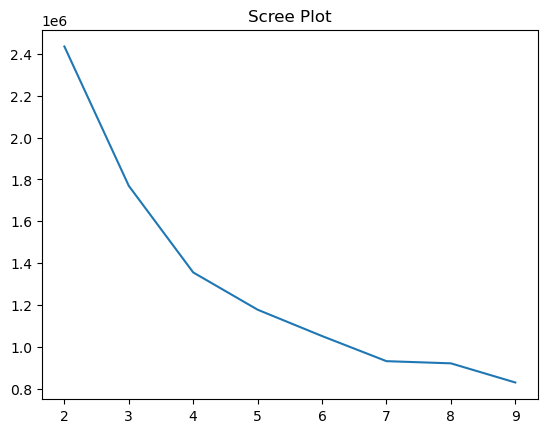

In [70]:
ks = range(2, 10)
inertias = []
#mdata['density_proxy_capped'] = mdata['density_proxy'].map(lambda x: min(x, 5000))
for i in ks:
    clust_model = KMeans(n_clusters=i, random_state=42, n_init='auto').fit(mdata[['cvap_white_pct', 'cvap_aapi_pct', 'cvap_black_pct',
                                                                                 'cvap_hisp_pct', 'cvap_natam_pct', 'college', 'urban_pct']])
    inertias.append(clust_model.inertia_)

plt.plot(ks, inertias)
plt.title('Scree Plot');

In [71]:
# ks = range(2, 10)
# inertias = []
# for i in ks:
#     clust_model = KMeans(n_clusters=i, random_state=42, n_init='auto').fit(mdata[['density_proxy']])
#     inertias.append(clust_model.inertia_)

# plt.plot(ks, inertias)
# plt.title('Scree Plot');

In [72]:
mdata_demo_forclust = mdata.set_index(['district', 'year'])
# mdata_demo_forclust = mdata_demo_forclust[['cvap_white_pct', 'cvap_aapi_pct', 'cvap_black_pct',
#                                                                                  'cvap_hisp_pct', 'cvap_natam_pct', 'college', 
#                                                                                   'density_proxy']]
# mdata_demo_forclust['density_proxy_capped'] = mdata_demo_forclust['density_proxy'].map(lambda x: min(x, 5000))
clust_model = KMeans(n_clusters=7, random_state=2026, n_init='auto').fit(mdata_demo_forclust[['cvap_white_pct', 'cvap_aapi_pct', 'cvap_black_pct',
                                                                                 'cvap_hisp_pct', 'cvap_natam_pct', 'college', 'urban_pct']])#, 'density_proxy_capped']])
mdata['demo_cluster'] = clust_model.labels_
mdata['district_id'] = mdata['district'].str.replace('-', '')

In [73]:
clust_model.cluster_centers_

array([[72.58372645,  6.00370458,  9.07576062, 10.32092425,  0.43136317,
        43.90012324, 93.91773325],
       [79.84635884,  2.62753997,  7.15033837,  8.17317005,  0.68304874,
        23.05667932, 82.76580869],
       [89.96216214,  1.00056187,  3.82110859,  2.93729738,  1.02021612,
        22.29821501, 52.87727466],
       [35.43475527,  3.35351647, 50.69691847,  8.8981978 ,  0.31119132,
        25.69366972, 92.43626077],
       [69.32904844,  1.58361396, 20.84216529,  5.33199012,  1.54649701,
        24.03405904, 59.830313  ],
       [25.70873578,  6.28108982,  9.90550391, 56.2957124 ,  0.84702939,
        19.01097778, 94.34385993],
       [48.48467039, 14.78819888, 10.10180367, 23.33153156,  0.7217579 ,
        31.68347403, 95.11763095]])

In [74]:
joblib.dump(clust_model, 'model/demographic_kmeans.pkl')

['model/demographic_kmeans.pkl']

In [75]:
for party in ['dem', 'rep']:
    mdata[f'{party}_funds_2p_pct'] = mdata[f'{party}_funds_2p_pct'].fillna(0)

In [76]:
# Export 2014 data to merge with 2012 data
dat_14 = mdata[mdata['year'] == 2014]
dat_14.to_csv('transformed/data_2014.csv')

In [77]:
# Exclude uncontested races and races w/ all candidates from one party
mdata['no_dem_cand_flag'] = mdata['dem_cand'].map(lambda x: x == '[]')
mdata['no_rep_cand_flag'] = mdata['rep_cand'].map(lambda x: x == '[]')
uncontested = mdata[(mdata['no_dem_cand_flag']) | (mdata['no_rep_cand_flag'])]
mdata = mdata[~mdata['no_dem_cand_flag']]
mdata = mdata[~mdata['no_rep_cand_flag']]
mdata.head()

,year,state,state_po,special,district,dem,rep,totalvotes,dem_cand,rep_cand,...,college,urban,rural,urban_pct,rural_pct,dem_2p_12,demo_cluster,district_id,no_dem_cand_flag,no_rep_cand_flag
0,2014,Alabama,AL,False,AL-01,48278.0,103758.0,152234,Burton R Leflore,Bradley Byrne,...,6.9,456228.0,226592.0,66.815266,33.184734,NaN,4,AL01,False,False
1,2014,Alabama,AL,False,AL-02,54692.0,113103.0,167952,Erick Wright,Martha Roby,...,6.3,373585.0,309235.0,54.712076,45.287924,NaN,4,AL02,False,False
2,2014,Alabama,AL,False,AL-03,52816.0,103558.0,156620,Jesse T Smith,Mike Rogers,...,6.7,343078.0,339741.0,50.244355,49.755645,NaN,4,AL03,False,False
5,2014,Alabama,AL,False,AL-06,42291.0,135945.0,178449,Mark Lester,Gary Palmer,...,11.3,472327.0,210492.0,69.173090,30.826910,NaN,1,AL06,False,False
7,2014,Alaska,AK,False,AK-00,114602.0,142572.0,279741,Forrest Dunbar,Don Young,...,5.4,468893.0,241338.0,66.019788,33.980212,NaN,4,AK00,False,False


In [78]:
for col in ['dem_inc', 'rep_inc']:
    mdata[col] = mdata[col].map(lambda x: ast.literal_eval(x))
mdata['dem_inc_any'] = mdata['dem_inc'].map(lambda x: x if not isinstance(x, list) else (True if True in x else False))
mdata['rep_inc_any'] = mdata['rep_inc'].map(lambda x: x if not isinstance(x, list) else (True if True in x else False))

In [79]:
mdata['dem_inc_dummy'] = mdata['dem_inc_any'].map(lambda x: 1 if x == True else 0)
mdata['rep_inc_dummy'] = mdata['rep_inc_any'].map(lambda x: 1 if x == True else 0)

In [80]:
mdata['pvi'] = mdata['prev_lean'] * 0.75 + mdata['prev2_lean'] * 0.25
mdata.head()

,year,state,state_po,special,district,dem,rep,totalvotes,dem_cand,rep_cand,...,dem_2p_12,demo_cluster,district_id,no_dem_cand_flag,no_rep_cand_flag,dem_inc_any,rep_inc_any,dem_inc_dummy,rep_inc_dummy,pvi
0,2014,Alabama,AL,False,AL-01,48278.0,103758.0,152234,Burton R Leflore,Bradley Byrne,...,NaN,4,AL01,False,False,False,True,0,1,-14.460266
1,2014,Alabama,AL,False,AL-02,54692.0,113103.0,167952,Erick Wright,Martha Roby,...,NaN,4,AL02,False,False,False,True,0,1,-16.091761
2,2014,Alabama,AL,False,AL-03,52816.0,103558.0,156620,Jesse T Smith,Mike Rogers,...,NaN,4,AL03,False,False,False,True,0,1,-15.311107
5,2014,Alabama,AL,False,AL-06,42291.0,135945.0,178449,Mark Lester,Gary Palmer,...,NaN,1,AL06,False,False,False,False,0,0,-27.395373
7,2014,Alaska,AK,False,AK-00,114602.0,142572.0,279741,Forrest Dunbar,Don Young,...,NaN,4,AK00,False,False,False,True,0,1,-10.647773


In [81]:
mdata.head(3)

,year,state,state_po,special,district,dem,rep,totalvotes,dem_cand,rep_cand,...,dem_2p_12,demo_cluster,district_id,no_dem_cand_flag,no_rep_cand_flag,dem_inc_any,rep_inc_any,dem_inc_dummy,rep_inc_dummy,pvi
0,2014,Alabama,AL,False,AL-01,48278.0,103758.0,152234,Burton R Leflore,Bradley Byrne,...,NaN,4,AL01,False,False,False,True,0,1,-14.460266
1,2014,Alabama,AL,False,AL-02,54692.0,113103.0,167952,Erick Wright,Martha Roby,...,NaN,4,AL02,False,False,False,True,0,1,-16.091761
2,2014,Alabama,AL,False,AL-03,52816.0,103558.0,156620,Jesse T Smith,Mike Rogers,...,NaN,4,AL03,False,False,False,True,0,1,-15.311107


In [82]:
mdata.shape

(2331, 53)

In [83]:
state_to_census_region = {
    'Connecticut': 'New England',
    'Maine': 'New England',
    'Massachusetts': 'New England',
    'New Hampshire': 'New England',
    'Rhode Island': 'New England',
    'Vermont': 'New England',
    'New Jersey': 'Mid-Atlantic',
    'New York': 'Mid-Atlantic',
    'Pennsylvania': 'Mid-Atlantic',
    'Illinois': 'East North Central',
    'Indiana': 'East North Central',
    'Michigan': 'East North Central',
    'Ohio': 'East North Central',
    'Wisconsin': 'East North Central',
    'Iowa': 'West North Central',
    'Kansas': 'West North Central',
    'Minnesota': 'West North Central',
    'Missouri': 'West North Central',
    'Nebraska': 'West North Central',
    'North Dakota': 'West North Central',
    'South Dakota': 'West North Central',
    'Delaware': 'South Atlantic',
    'Maryland': 'South Atlantic',
    'Florida': 'South Atlantic',
    'Georgia': 'South Atlantic',
    'North Carolina': 'South Atlantic',
    'South Carolina': 'South Atlantic',
    'Virginia': 'South Atlantic',
    'West Virginia': 'South Atlantic',
    'Alabama': 'East South Central',
    'Kentucky': 'East South Central',
    'Mississippi': 'East South Central',
    'Tennessee': 'East South Central',
    'Arkansas': 'West South Central',
    'Louisiana': 'West South Central',
    'Oklahoma': 'West South Central',
    'Texas': 'West South Central',
    'Arizona': 'Mountain',
    'Colorado': 'Mountain',
    'Idaho': 'Mountain',
    'Montana': 'Mountain',
    'Nevada': 'Mountain',
    'New Mexico': 'Mountain',
    'Utah': 'Mountain',
    'Wyoming': 'Mountain',
    'California': 'Pacific',
    'Alaska': 'Pacific',
    'Oregon': 'Pacific',
    'Washington': 'Pacific',
    'Hawaii': 'Pacific'
}

In [84]:
mdata['census_region'] = mdata['state'].map(state_to_census_region)

In [85]:
## Political scandals
# List of scandals by federal and state officeholders courtesy of Nathaniel Rakich
scandals = pd.read_csv('https://docs.google.com/spreadsheets/d/1ksBLxRR3GCZd33IvhkcNqqBd5K8HwlWC7YuAkVmS1lg/export?format=csv')
scandals.to_csv('data/rakich_scandals.csv')
scandals = scandals.set_axis(['politician', 'state', 'position', 'year', 'type', 'outcome', 'comeback'], axis=1)
scandals['politician'] = scandals['politician'].map(lambda x: unicodedata.normalize('NFC', x))
scandals.head()

,politician,state,position,year,type,outcome,comeback
0,Dale Caldwell,New Jersey,Lieutenant Governor,2026,"Sexual harassment, ethics",TBD,NaN
1,Jimmy Gomez,California,Representative,2026,Affair with staffer,TBD,NaN
2,Liz Murrill,Louisiana,Attorney General,2026,Intimidation,TBD,NaN
3,Jim Costa,California,Representative,2026,Sexual harassment,TBD,NaN
4,Chuck Edwards,North Carolina,Representative,2026,Sexual harassment,TBD,NaN


In [86]:
def get_scandals(politician, state, cycle):
    # :param cycle: The year of the election cycle
    mask = ((scandals['state'] == state) & (scandals['year'] <= cycle))
    scan_df = scandals[mask]
    fuzzymatch = process.extractOne(politician, scan_df['politician'], scorer=fuzz.WRatio, score_cutoff=90)
    if fuzzymatch is None:
        return 0
    scan_df_pol = scan_df[scan_df['politician'] == fuzzymatch[0]]
    # Exponential decay factor to put less weight on older scandals relative to newer scandals
    # e^(-\delta_t/4)
    scan_df_pol['decay_factor'] = np.exp(-(scan_df_pol['year'].astype(int).map(lambda x: cycle - x))/4)
    pol_scandal_score = scan_df_pol.groupby(['politician']).agg({'decay_factor': 'sum'})['decay_factor'].values[0]
    return pol_scandal_score

In [87]:
mdata['dem_scandal_score'] = mdata.apply(lambda x: get_scandals(x['dem_cand'], x['state'], x['year']), axis=1)
mdata['rep_scandal_score'] = mdata.apply(lambda x: get_scandals(x['rep_cand'], x['state'], x['year']), axis=1)
mdata['net_scandal_score'] = mdata['dem_scandal_score'] - mdata['rep_scandal_score']
mdata.head()

,year,state,state_po,special,district,dem,rep,totalvotes,dem_cand,rep_cand,...,no_rep_cand_flag,dem_inc_any,rep_inc_any,dem_inc_dummy,rep_inc_dummy,pvi,census_region,dem_scandal_score,rep_scandal_score,net_scandal_score
0,2014,Alabama,AL,False,AL-01,48278.0,103758.0,152234,Burton R Leflore,Bradley Byrne,...,False,False,True,0,1,-14.460266,East South Central,0.0,0.0,0.0
1,2014,Alabama,AL,False,AL-02,54692.0,113103.0,167952,Erick Wright,Martha Roby,...,False,False,True,0,1,-16.091761,East South Central,0.0,0.0,0.0
2,2014,Alabama,AL,False,AL-03,52816.0,103558.0,156620,Jesse T Smith,Mike Rogers,...,False,False,True,0,1,-15.311107,East South Central,0.0,0.0,0.0
5,2014,Alabama,AL,False,AL-06,42291.0,135945.0,178449,Mark Lester,Gary Palmer,...,False,False,False,0,0,-27.395373,East South Central,0.0,0.0,0.0
7,2014,Alaska,AK,False,AK-00,114602.0,142572.0,279741,Forrest Dunbar,Don Young,...,False,False,True,0,1,-10.647773,Pacific,0.0,1.0,-1.0


In [88]:
mdata = mdata.replace({'Eli Crane': 'Elijah Crane', "['David Alexander', 'Jonathan Nez']": 'Jonathan Nez'})

In [89]:
stwar = pd.read_csv('data/split_ticket_war_dataset.csv')
stwar = stwar[stwar['Chamber'] == 'House']
stwar['Geography'] = stwar['Geography'].map(lambda x: x[:2] + '-00' if x[3:] == 'AL' else x).astype(str)
stwar['Year']  = stwar['Year'].astype(int)
stwar.head()

,Year,Chamber,Geography,Democrat,Republican,WAR,Sortable
0,2024,House,AL-01,Tom Holmes,Barry Moore,D+1.3,-1.3
1,2024,House,AL-02,Shomari Figures,Caroleene Dobson,D+2.2,-2.2
2,2024,House,AL-06,Elizabeth Anderson,Gary Palmer,D+4.5,-4.5
3,2024,House,AL-07,Terri Sewell,Robin Litaker,R+0.2,0.2
4,2024,House,AK-00,Mary Peltola,Nick Begich,D+9.1,-9.1


In [90]:
mdata = pd.merge(left=mdata, right=stwar[['Year', 'Geography', 'Democrat', 'Republican']], left_on=['year', 'district'], right_on=['Year', 'Geography'],
               how='left')
mdata.head()

,year,state,state_po,special,district,dem,rep,totalvotes,dem_cand,rep_cand,...,rep_inc_dummy,pvi,census_region,dem_scandal_score,rep_scandal_score,net_scandal_score,Year,Geography,Democrat,Republican
0,2014,Alabama,AL,False,AL-01,48278.0,103758.0,152234,Burton R Leflore,Bradley Byrne,...,1,-14.460266,East South Central,0.0,0.0,0.0,2014.0,AL-01,Burton LeFlore,Bradley Byrne
1,2014,Alabama,AL,False,AL-02,54692.0,113103.0,167952,Erick Wright,Martha Roby,...,1,-16.091761,East South Central,0.0,0.0,0.0,2014.0,AL-02,Erick Wright,Martha Roby
2,2014,Alabama,AL,False,AL-03,52816.0,103558.0,156620,Jesse T Smith,Mike Rogers,...,1,-15.311107,East South Central,0.0,0.0,0.0,2014.0,AL-03,Jesse Smith,Mike Rogers
3,2014,Alabama,AL,False,AL-06,42291.0,135945.0,178449,Mark Lester,Gary Palmer,...,0,-27.395373,East South Central,0.0,0.0,0.0,2014.0,AL-06,Mark Lester,Gary Palmer
4,2014,Alaska,AK,False,AK-00,114602.0,142572.0,279741,Forrest Dunbar,Don Young,...,1,-10.647773,Pacific,0.0,1.0,-1.0,2014.0,AK-00,Forrest Dunbar,Don Young


In [91]:
mdata = mdata.rename({'Democrat': 'dem_stand', 'Republican': 'rep_stand'}, axis=1)
for party in ['dem', 'rep']:
    mdata[f'{party}_stand'] = mdata[f'{party}_stand'].fillna(mdata[f'{party}_cand'])
    mdata[f'{party}_cand'] = mdata[f'{party}_stand']

In [92]:
mdata = mdata.replace({
    'Mark Desaulnier': 'Mark DeSaulnier',
    'Monica de la Cruz': 'Monica De La Cruz',
    'Scott Desjarlais': 'Scott DesJarlais',
    'Donald Payne': 'Donald Payne Jr.',
    'Filemon Vela': 'Filemon Vela Jr.',
    'Stewart Mills III': 'Stewart Mills',
    'GK Butterfield': 'G.K. Butterfield',
    'Garret Graves*': 'Garret Graves'
})

In [93]:
mdata['inc_dummy'] = mdata['dem_inc_dummy'] - mdata['rep_inc_dummy']
mdata.head()

,year,state,state_po,special,district,dem,rep,totalvotes,dem_cand,rep_cand,...,pvi,census_region,dem_scandal_score,rep_scandal_score,net_scandal_score,Year,Geography,dem_stand,rep_stand,inc_dummy
0,2014,Alabama,AL,False,AL-01,48278.0,103758.0,152234,Burton LeFlore,Bradley Byrne,...,-14.460266,East South Central,0.0,0.0,0.0,2014.0,AL-01,Burton LeFlore,Bradley Byrne,-1
1,2014,Alabama,AL,False,AL-02,54692.0,113103.0,167952,Erick Wright,Martha Roby,...,-16.091761,East South Central,0.0,0.0,0.0,2014.0,AL-02,Erick Wright,Martha Roby,-1
2,2014,Alabama,AL,False,AL-03,52816.0,103558.0,156620,Jesse Smith,Mike Rogers,...,-15.311107,East South Central,0.0,0.0,0.0,2014.0,AL-03,Jesse Smith,Mike Rogers,-1
3,2014,Alabama,AL,False,AL-06,42291.0,135945.0,178449,Mark Lester,Gary Palmer,...,-27.395373,East South Central,0.0,0.0,0.0,2014.0,AL-06,Mark Lester,Gary Palmer,0
4,2014,Alaska,AK,False,AK-00,114602.0,142572.0,279741,Forrest Dunbar,Don Young,...,-10.647773,Pacific,0.0,1.0,-1.0,2014.0,AK-00,Forrest Dunbar,Don Young,-1


In [94]:
res_12 = pd.read_csv('transformed/house_and_pres_res_2012.csv')
corr_12 = np.corrcoef(res_12['dem_2p_pct'], res_12['dem_2p_12'])[0, 1]
polariz_coeffs = {2014: float(corr_12)}

for yr in np.unique(data['year']):
    prev_gen_cyc = yr - 2 # previous House election cycle
    if yr == 2014:
        continue
    df = mdata[mdata['year'] == prev_gen_cyc]

    # Get polarization (correlation coefficient between previous presidential vote and current House cycle [prev_gen_cyc])
    polariz = np.corrcoef(df['dem_pct_2p'], df['dem_2p_prev'])
    polariz_coeffs.update({int(yr): float(polariz[0, 1])})

In [95]:
mdata['polarization'] = mdata['year'].map(polariz_coeffs)
mdata.head(2)

,year,state,state_po,special,district,dem,rep,totalvotes,dem_cand,rep_cand,...,census_region,dem_scandal_score,rep_scandal_score,net_scandal_score,Year,Geography,dem_stand,rep_stand,inc_dummy,polarization
0,2014,Alabama,AL,False,AL-01,48278.0,103758.0,152234,Burton LeFlore,Bradley Byrne,...,East South Central,0.0,0.0,0.0,2014.0,AL-01,Burton LeFlore,Bradley Byrne,-1,0.875383
1,2014,Alabama,AL,False,AL-02,54692.0,113103.0,167952,Erick Wright,Martha Roby,...,East South Central,0.0,0.0,0.0,2014.0,AL-02,Erick Wright,Martha Roby,-1,0.875383


In [96]:
# Fix duplicate names belonging to different candidates
dem_corrections = {
    ('GA-05', 'John Lewis'): 'John Robert Lewis',
    ('SC-07', 'Robert Williams'): 'Robert Quintin Williams'
}

rep_corrections = {
    ('MI-13', 'Jeff Gorman'): 'Jeff Gorman (Michigan)',
}

In [97]:
for (cd, cand) in dem_corrections.keys():
    mask = (
        (mdata['district'] == cd) &
        (mdata['dem_cand'] == cand)
    )

    mdata.loc[mask, 'dem_cand'] = dem_corrections[(cd, cand)]

for (cd, cand) in rep_corrections.keys():
    mask = (
        (mdata['district'] == cd) &
        (mdata['rep_cand'] == cand)
    )

    mdata.loc[mask, 'rep_cand'] = rep_corrections[(cd, cand)]

In [98]:
mdata.shape

(2331, 63)

In [100]:
mdata.head()

,year,state,state_po,special,district,dem,rep,totalvotes,dem_cand,rep_cand,...,census_region,dem_scandal_score,rep_scandal_score,net_scandal_score,Year,Geography,dem_stand,rep_stand,inc_dummy,polarization
0,2014,Alabama,AL,False,AL-01,48278.0,103758.0,152234,Burton LeFlore,Bradley Byrne,...,East South Central,0.0,0.0,0.0,2014.0,AL-01,Burton LeFlore,Bradley Byrne,-1,0.875383
1,2014,Alabama,AL,False,AL-02,54692.0,113103.0,167952,Erick Wright,Martha Roby,...,East South Central,0.0,0.0,0.0,2014.0,AL-02,Erick Wright,Martha Roby,-1,0.875383
2,2014,Alabama,AL,False,AL-03,52816.0,103558.0,156620,Jesse Smith,Mike Rogers,...,East South Central,0.0,0.0,0.0,2014.0,AL-03,Jesse Smith,Mike Rogers,-1,0.875383
3,2014,Alabama,AL,False,AL-06,42291.0,135945.0,178449,Mark Lester,Gary Palmer,...,East South Central,0.0,0.0,0.0,2014.0,AL-06,Mark Lester,Gary Palmer,0,0.875383
4,2014,Alaska,AK,False,AK-00,114602.0,142572.0,279741,Forrest Dunbar,Don Young,...,Pacific,0.0,1.0,-1.0,2014.0,AK-00,Forrest Dunbar,Don Young,-1,0.875383


In [99]:
mdata.to_csv('transformed/all_2p_house_races_trainset.csv')